In [1]:
import matplotlib.pyplot as plt
import numpy

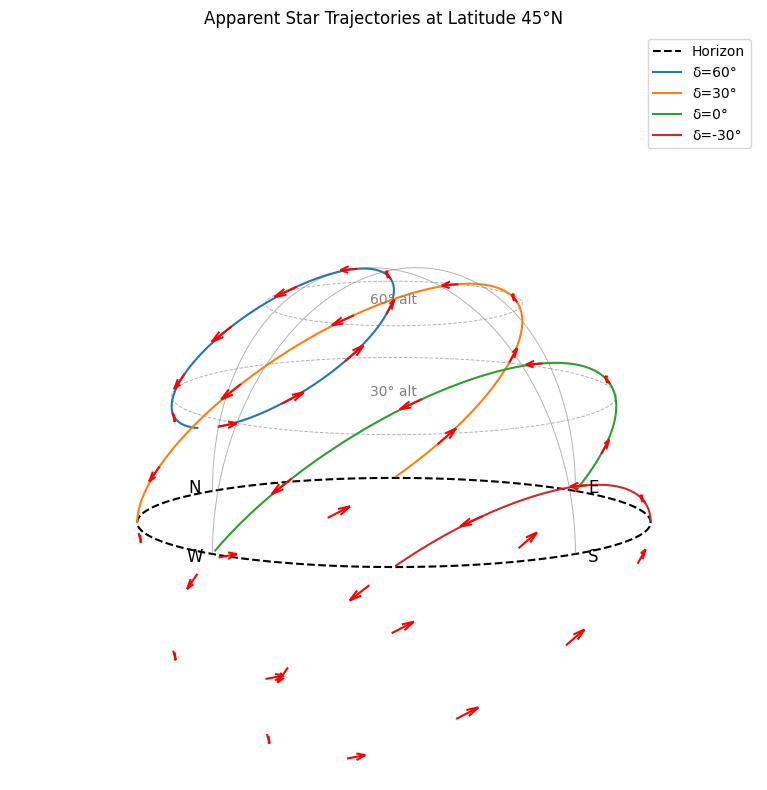

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Observer latitude (medium latitude)
latitude_deg = 45.0
lat = np.radians(latitude_deg)

# ---- Helper: Convert RA/Dec to alt-az Cartesian ----
def radec_to_altaz_cart(ra_hours, dec_deg, lst_hours, lat_rad):
    ha_deg = (lst_hours - ra_hours) * 15.0  # hour angle in degrees
    ha = np.radians(ha_deg)
    dec = np.radians(dec_deg)
    alt = np.arcsin(np.sin(lat_rad)*np.sin(dec) + np.cos(lat_rad)*np.cos(dec)*np.cos(ha))
    az = np.arctan2(-np.sin(ha), np.cos(lat_rad)*np.tan(dec) - np.sin(lat_rad)*np.cos(ha))
    # Cartesian conversion (z up)
    x = np.cos(alt) * np.sin(az)
    y = np.cos(alt) * np.cos(az)
    z = np.sin(alt)
    return x, y, z

# ---- Build Figure ----
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect([1,1,0.5])

# Horizon circle (z=0)
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), 'k--', lw=1.5, label='Horizon')

# Cardinal direction labels (E,N,W,S)
labels = {'E':(1.1,0,0), 'N':(0,1.1,0), 'W':(-1.1,0,0), 'S':(0,-1.1,0)}
for txt,(x,y,z) in labels.items():
    ax.text(x, y, z, txt, ha='center', va='center', fontsize=12)

# Draw altitude circles (like 30°, 60° above horizon)
altitudes = np.radians([30, 60])
for alt in altitudes:
    r = np.cos(alt)
    z = np.sin(alt)
    ax.plot(r*np.cos(theta), r*np.sin(theta), np.full_like(theta,z), 
            '--', lw=0.7, color='gray', alpha=0.6)
    ax.text(0,0,z, f'{np.degrees(alt):.0f}° alt', color='gray', ha='center')

# Draw azimuth meridians (0°=N,90°=E,etc)
azimuths = np.radians([0,90,180,270])
for az in azimuths:
    alt = np.linspace(0, np.pi/2, 100)
    x = np.cos(alt)*np.sin(az)
    y = np.cos(alt)*np.cos(az)
    z = np.sin(alt)
    ax.plot(x, y, z, color='gray', lw=0.7, alpha=0.6)

# ---- Plot several star trajectories (constant Dec circles) ----
ras = np.linspace(12, -11, 200)
for dec_deg in [60, 30, 0, -30]:
    xs, ys, zs = [], [], []
    for ra in ras:
        x,y,z = radec_to_altaz_cart(ra, dec_deg, lst_hours=0, lat_rad=lat)
        xs.append(x); ys.append(y); zs.append(z)
    # keep only points above horizon
    xs, ys, zs = np.array(xs), np.array(ys), np.array(zs)
    above = zs >= 0
    ax.plot(xs[above], ys[above], zs[above], lw=1.5, label=f"δ={dec_deg}°")

    dx = np.gradient(xs)
    dy = np.gradient(ys)
    dz = np.gradient(zs)

    # Add arrows along the path
    skip = 20  # plot every 5 points to avoid clutter
    ax.quiver(xs[::skip], ys[::skip], zs[::skip], 
            dx[::skip], dy[::skip], dz[::skip], 
            length=0.1, normalize=True, color='red', arrow_length_ratio=0.5)

# ---- Labels & cosmetics ----
ax.set_title(f"Apparent Star Trajectories at Latitude {latitude_deg:.0f}°N")
ax.set_xlabel('East-West (x)')
ax.set_ylabel('North-South (y)')
ax.set_zlabel('Altitude (z)')
ax.legend()
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(0,1)
ax.set_axis_off()
ax.view_init(elev=10, azim=-135)
plt.tight_layout()
plt.show()
